In [1]:
# моделирование траекторий
# броуновского движения
# в неограниченой области

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

import random

random.seed()

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей координаты траектории
# классического броуновского движения,
# вычисленные в соответствие с
# нерекурсивным алгоритмом
# срединного смещения


def Mid_BM(Sigma, Ratio, Level):
    # вычисление числа шагов
    # броуновской частицы
    N = 2**Level

    # инициализация массива X
    X = np.zeros(N + 1)

    # вычисление координаты
    # броуновской частицы
    # на ее последнем шаге
    random.seed()
    X[0] = Sigma * random.gauss(0, 1)
    X[N] = Sigma * random.gauss(0, 1)

    # реализация вычислений
    # координат траектории
    # броуновской частицы
    # в соответствие с алгоритмом I
    for i in range(1, Level + 1):
        if i == 1:
            Number = np.array([N / 2**i, N / 2 ** (i - 1), 0], dtype=int)
            random.seed()
            X[Number[0]] = 0.5 * (X[Number[2]] + X[Number[1]]) + Ratio ** (
                (i + 1) / 2
            ) * Sigma * random.gauss(0, 1)

        if i == 2:
            for m in range(1, i + 1):
                Number = np.array(
                    [
                        (2 * m - 1) * N / 2**i,
                        m * N / 2 ** (i - 1),
                        (m - 1) * N / 2 ** (i - 1),
                    ],
                    dtype=int,
                )

                X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                    (i + 1) / 2
                ) * Sigma * random.gauss(0, 1)
        if i > 2:
            for m in range(1, 2 ** (i - 1) + 1):
                Number = np.array(
                    [
                        (2 * m - 1) * N / 2**i,
                        m * N / 2 ** (i - 1),
                        (m - 1) * N / 2 ** (i - 1),
                    ],
                    dtype=int,
                )

                X[Number[0]] = 0.5 * (X[Number[1]] + X[Number[2]]) + Ratio ** (
                    (i + 1) / 2
                ) * Sigma * random.gauss(0, 1)

    return X


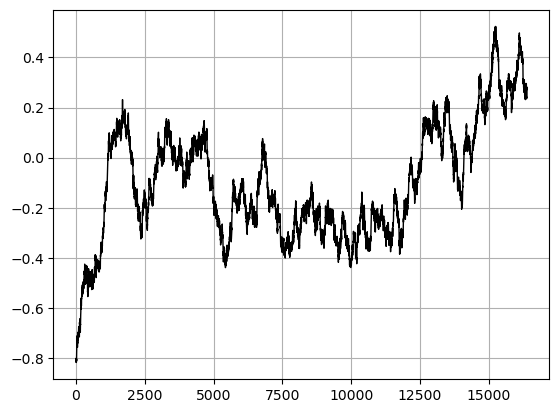

In [3]:
# Ячейка № 3
# вычисление координат траектории
# классического броуновского движения,
# в соответствие с нерекурсивным алгоритмом
# срединного смещения

# задание значения числа n
# (в описании алгоритма)
Level = 14

# задание значения
# масштабирующего множителя
Sigma = 1

# задание значения
# коэффициента скэйлинга
Ratio = 0.5

X = Mid_BM(Sigma, Ratio, Level)

# визуализация траектории
# броуновской частицы
plt.plot(X, "-k", lw=1)
plt.grid("True")

plt.show()

In [4]:
# Ячейка № 4

# задание рекурсивной функции,
# возвращающий значения координат
# траектории броуновской
# частицы, совершающей блуждания
# в неограниченной области рассеяния
def Divide2Part_BM(X, Ratio, Sigma, I0, I2, Level, Max_Level):
    # входные переменные:
    # X - массив, содержащий координаты
    #     траектории броуновской частицы
    #     возвращенных на предыдущем уровне рекурсии
    # Ratio - коэффициент скэйлинга
    # Sigma - масштабирующий множитель
    # Std - масштабирующий коэффициент,
    #       вычисленный на предыдущем
    #       уровне рекурсии
    # I0, I2 - номера крайне левой и крайне
    #          правой точек отрезка на предыдущем
    #          уровне рекурсии, в середине которого
    #          вычисляется значение траектории
    #          броуновской частицы
    # Level - номер предыдущего уровня рекурсии
    # MaxLevel - соответствует числу n в описании
    #            алгоритма № II

    # вычисление координаты
    # середины отрезка [I0, I2]
    I1 = (I0 + I2) // 2

    # вычисление значения
    # I1-ой координаты траектории
    # броуновской частицы

    X[I1] = 0.5 * (X[I0] + X[I2]) + Ratio ** (Level / 2) * Sigma * random.gauss(
        0, Sigma
    )

    # рекурсия
    if Level <= Max_Level - 1:
        # вычисление координаты
        # траектории броуновской частицы
        # в середине отрезка [I0, I1]
        X = Divide2Part_BM(X, Ratio, Sigma, I0, I1, Level + 1, Max_Level)

        # вычисление координаты
        # траектории броуновской частицы
        # в середине отрезка [I1, I2]
        X = Divide2Part_BM(X, Ratio, Sigma, I1, I2, Level + 1, Max_Level)
    return X

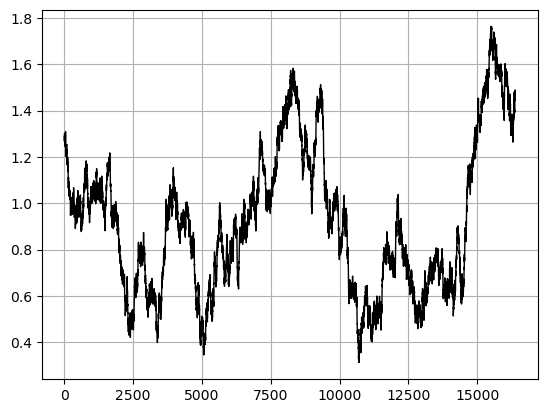

In [5]:
# Ячейка № 5

# задание значения числа n
# (в описании алгоритма)
Max_Level = 14

# задание значения
# масштабирующего множителя
Sigma = 1

# задание значения
# коэффициента скэйлинга
Ratio = 0.5

# вычисление числа шагов
# броуновской частицы
N = 2**Max_Level

# вычисление значения
# масштабирующего коэффициента,
# используемого на первом уровне рекурсии
Std = Sigma * Ratio

# инициализация счетчика уровней рекурсии
Level = 1

# инициализация массива,
# используемого для охранения
# координат траектории
# броуновской частицы
X = np.zeros(N + 1)

# вычисление координаты
# броуновской частицы
# на ее последнем шаге
random.seed(1)
X[0] = Sigma * random.gauss(0, 1)

X[N] = Sigma * random.gauss(0, 1)

I0 = 0
I2 = N

# вычисление координат
# траектории броуновской частицы
# в соответствие с алгоритмом II
Divide2Part_BM(X, Ratio, Sigma, I0, I2, Level, Max_Level)

# визуализация траектории
# броуновской частицы
plt.plot(X, "-k", lw=1)
plt.grid("True")

plt.show()